# DCGAN — interpretable latent directions (GANSpace)

Finding directions in a trained GAN that correspond to interpretable changes (pose, lighting, hair, ...) — the idea from **GANSpace** (Härkönen et al., 2020), applied to the DCGAN trained in `dcgan_experiments.ipynb`.

In StyleGAN, GANSpace runs PCA on the *W* space — the learned intermediate latent produced by the mapping network. DCGAN has no such space: its input `z` is plain isotropic `N(0, I)`, so PCA on raw `z` finds nothing (every direction has equal variance by construction). The right analogue for a network without a *W* space — and what GANSpace itself does in that case — is to run PCA on the **activations of an early layer** and edit there. I use the first block's output (the 4x4 feature), which controls coarse, global attributes — the same role the early *W+* layers play in StyleGAN.

In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.decomposition import PCA

sys.path.append(os.path.abspath('..'))

from dcgan import Generator
from utils.utils import return_device

In [2]:
device = return_device()

Device is cuda


In [3]:
LATENT_DIM = 100  # must match training

G = Generator(latent_dim=LATENT_DIM).to(device)
G.load_state_dict(torch.load('../checkpoints/dcgan_generation.pt', map_location=device, weights_only=True))
G.eval()

# Split the generator: first block (ConvTranspose + BN + ReLU) -> 4x4 feature; the rest -> image.
head = nn.Sequential(*list(G.net)[:3])
tail = nn.Sequential(*list(G.net)[3:])

with torch.no_grad():
    probe = head(torch.randn(1, LATENT_DIM, 1, 1, device=device))
feat_shape = probe.shape[1:]  # (C, 4, 4)
flat_dim = int(np.prod(feat_shape))
print('first-layer feature:', tuple(feat_shape), '-> flattened', flat_dim)

first-layer feature: (512, 4, 4) -> flattened 8192


In [4]:
#  Collect first-layer features

N = 20000
batch = 500
feats = np.zeros((N, flat_dim), dtype=np.float32)
with torch.no_grad():
    for i in tqdm(range(0, N, batch)):
        k = min(batch, N - i)
        f = head(torch.randn(k, LATENT_DIM, 1, 1, device=device))
        feats[i:i + k] = f.reshape(k, -1).cpu().numpy()
print('features:', feats.shape)

  0%|          | 0/40 [00:00<?, ?it/s]

features: (20000, 8192)


## PCA

Principal components (sorted by explained variance) are the candidate interpretable directions. Editing along a component is scaled by its standard deviation, so the strength is in units of sigma.

In [5]:
n_components = 80
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42).fit(feats)
components = pca.components_  # (n_components, flat_dim), unit vectors
stds = np.sqrt(pca.explained_variance_)  # per-component std, for scaling edits
evr = pca.explained_variance_ratio_
print('components:', components.shape)

components: (80, 8192)


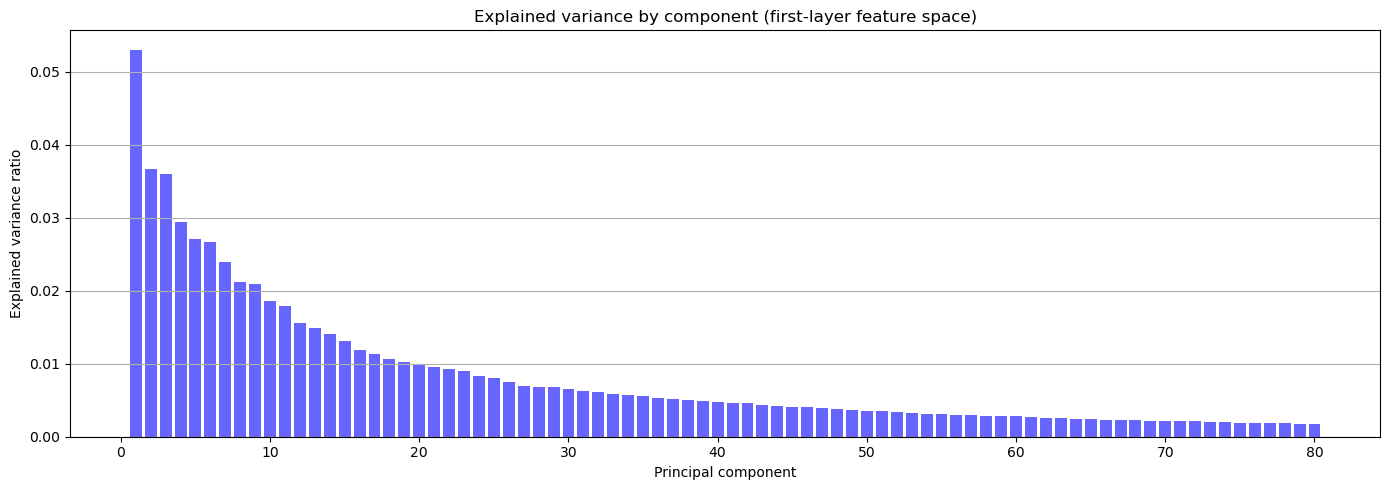

top-10 cumulative variance: 0.423


In [6]:
plt.figure(figsize=(14, 5))
plt.bar(np.arange(1, len(evr) + 1), evr, alpha=0.6, color='b')
plt.xlabel('Principal component'); plt.ylabel('Explained variance ratio')
plt.title('Explained variance by component (first-layer feature space)')
plt.grid(axis='y'); plt.tight_layout(); plt.show()

print('top-10 cumulative variance:', round(float(evr[:20].sum()), 3))

## Walk along a direction

For a fixed face, add `strength * sigma * component` to its first-layer feature and decode. The middle column (strength 0) is the unedited face; moving left and right walks the direction in both senses.

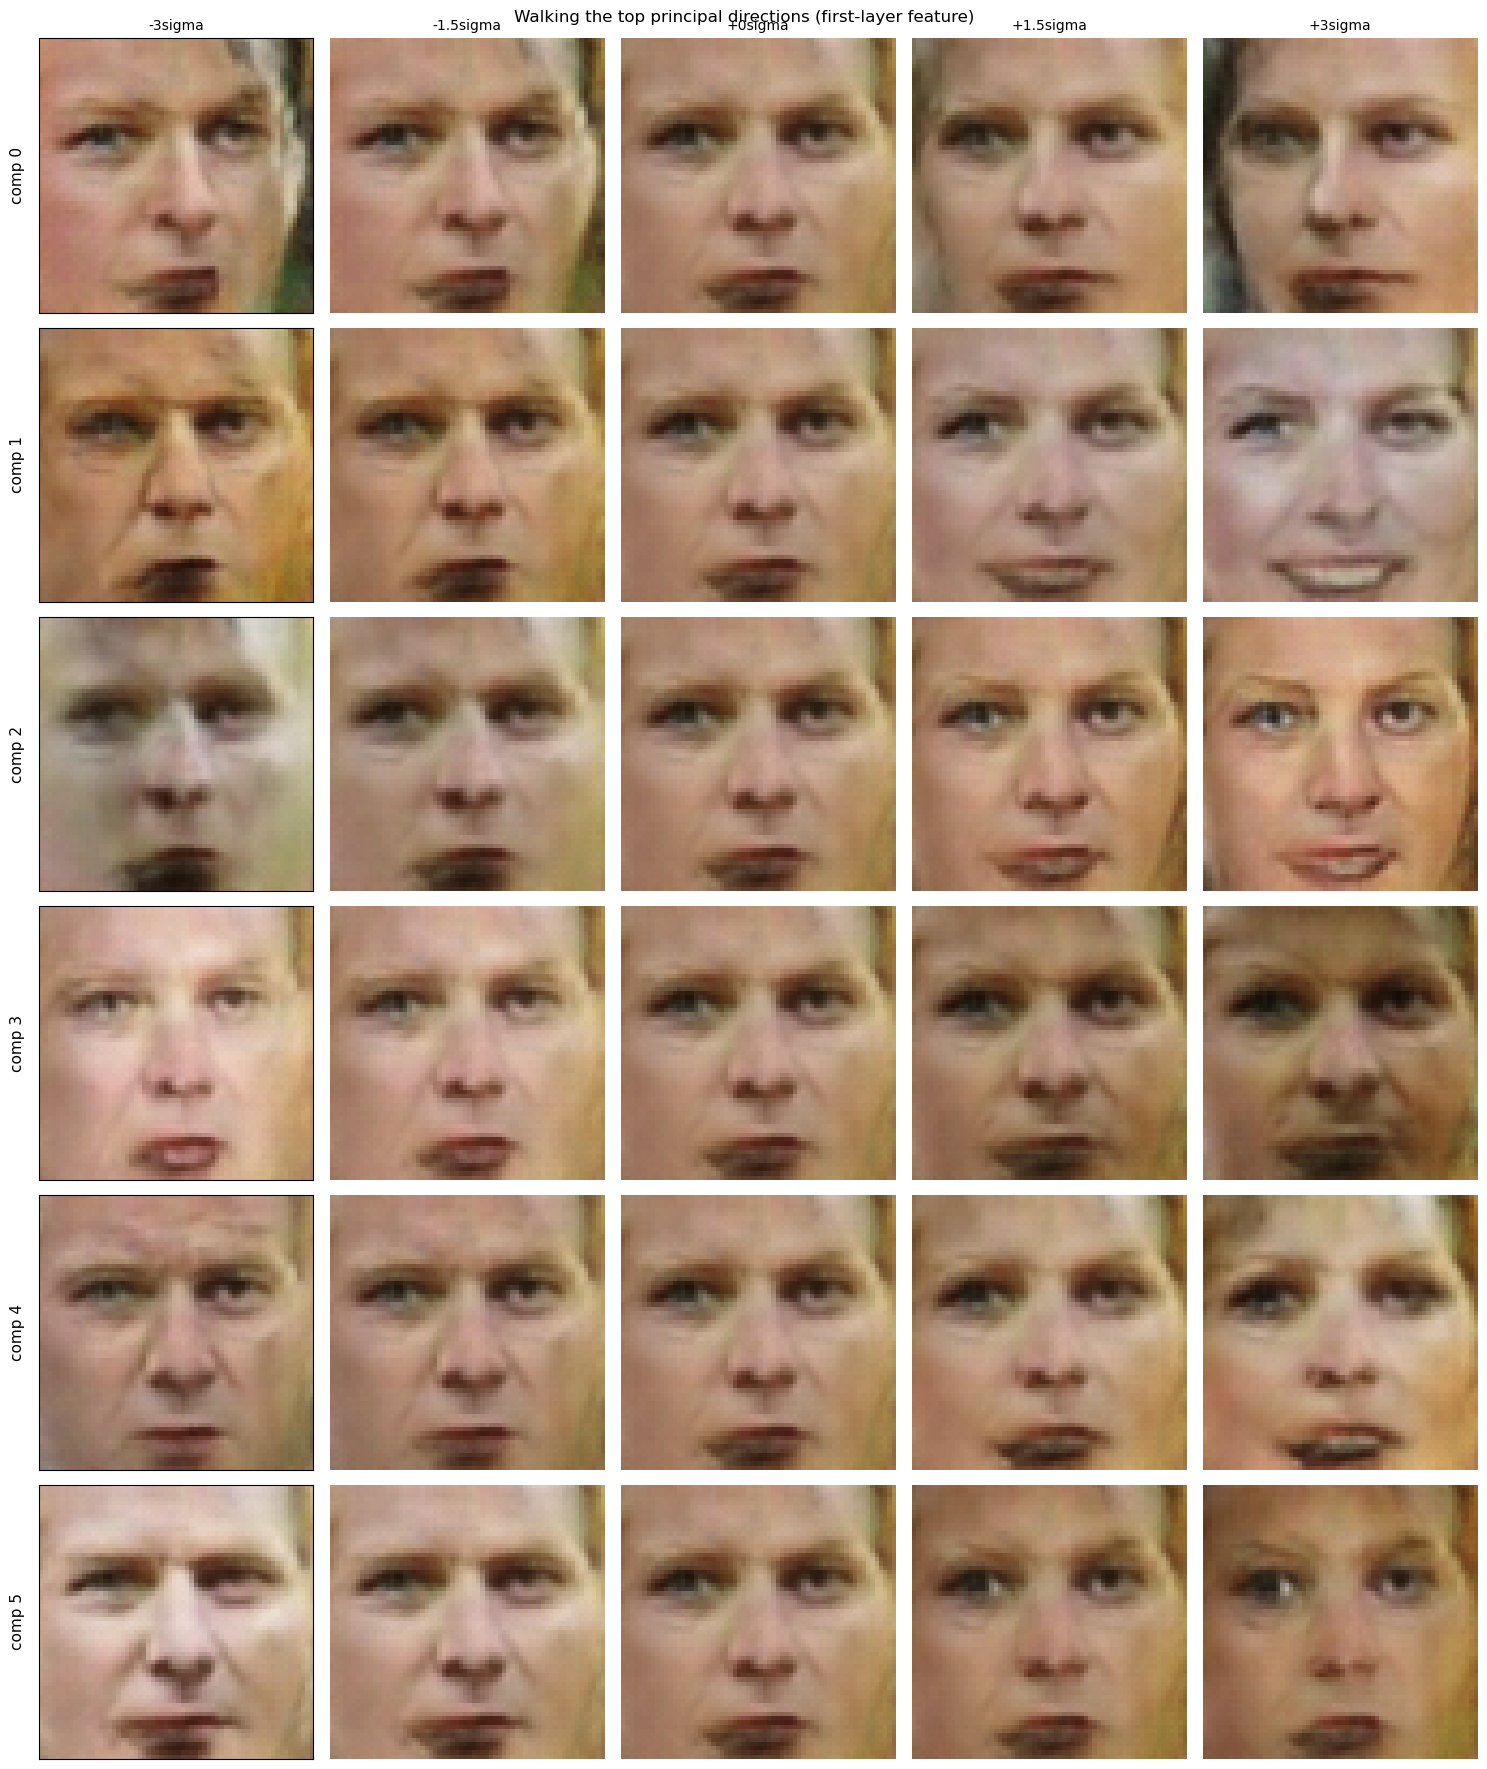

In [7]:
@torch.no_grad()
def edit(z, comp_idx, strength):
    """Add strength*sigma*component to the first-layer feature and decode -> image in [0,1]."""
    f = head(z)
    delta = torch.from_numpy(components[comp_idx]).to(device).view(feat_shape)
    f_ed = f + strength * float(stds[comp_idx]) * delta
    return ((tail(f_ed) + 1) / 2).clamp(0, 1)

seed = 41
top_k = 6  # how many components to scan
strengths = [-3, -1.5, 0, 1.5, 3]

gen = torch.Generator(device=device).manual_seed(seed)
z = torch.randn(1, LATENT_DIM, 1, 1, generator=gen, device=device)

fig, axes = plt.subplots(top_k, len(strengths), figsize=(3 * len(strengths), 3 * top_k))
for r in range(top_k):
    for c, s in enumerate(strengths):
        img = edit(z, r, s)[0].cpu().permute(1, 2, 0).numpy()
        axes[r, c].imshow(img); axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(f'{s:+g}sigma', fontsize=10)
    axes[r, 0].set_ylabel(f'comp {r}', fontsize=11, rotation=90, labelpad=10)
    axes[r, 0].axis('on'); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.suptitle('Walking the top principal directions (first-layer feature)')
plt.tight_layout(); plt.show()

## Interpretation

Some directions turned out interpretable. Not every component is nameable (the space is entangled — moving one often changes identity too), but the top few usually carry recognizable global factors.